# Task B-1: Prometheus Data Exploration

## Project Overview
**Prometheus** is an AI monitoring system designed for gym owners to analyze occupancy and machine usage while ensuring privacy (PDPA compliance).

## 1. Data Characteristics
- **Format**: 640x640 JPEG images (YOLO standard).
- **Classes**:
  - `0: person`
  - `1: gym-machine` (custom class fine-tuned for this project)

## 2. Dataset Structure
The dataset is organized into `train` and `val` splits using a **Strategic Slicing** strategy to ensure high variance in gym states (peak hours vs empty hours).

Project Root: c:\Users\Phasit\Desktop\Prometheus\Prometheus


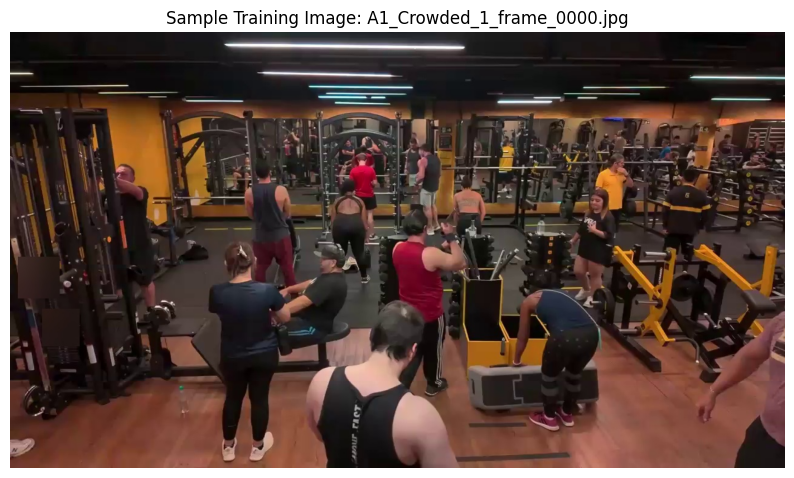

--- Dataset Summary (from final_dataset) ---
Total Training Images: 387
Instances found (sample of 100 images): 883 Persons, 492 Machines


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import glob

# 1. Find Project Root
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    ROOT_DIR = os.path.abspath(os.path.join(cwd, '..'))
else:
    ROOT_DIR = cwd

print(f"Project Root: {ROOT_DIR}")

# 2. Find Data Directory (PRIORITIZE final_dataset)
search_patterns = [
    os.path.join(ROOT_DIR, 'model/data/final_dataset/images/train/*.jpg'),
    os.path.join(ROOT_DIR, 'model/data/test_frames/images/train/*.jpg'),
    os.path.join(ROOT_DIR, 'model/data/processed_dataset/images/train/*.jpg')
]

found_img = None
data_dir = None
for pattern in search_patterns:
    files = glob.glob(pattern)
    if files:
        found_img = files[0]
        # data_dir is the root of the dataset
        data_dir = os.path.dirname(os.path.dirname(os.path.dirname(found_img)))
        break

if found_img:
    # 3. Visualize Sample
    img = cv2.imread(found_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.title(f"Sample Training Image: {os.path.basename(found_img)}")
    plt.axis('off')
    plt.show()
    
    # 4. Analyze Distribution
    label_files = glob.glob(os.path.join(data_dir, 'labels/train/*.txt'))
    print(f"--- Dataset Summary (from {os.path.basename(data_dir)}) ---")
    print(f"Total Training Images: {len(label_files)}")
    
    # Simple count of instances
    persons = 0
    machines = 0
    for lb in label_files[:100]: # Sample first 100
        with open(lb, 'r') as f:
            for line in f:
                if line.startswith('0 '): persons += 1
                if line.startswith('1 '): machines += 1
    
    print(f"Instances found (sample of 100 images): {persons} Persons, {machines} Machines")
else:
    print("❌ No images found. Please ensure you have run pre-processing.py and data_split.py.")

## 3. Privacy Compliance (PDPA)
As seen in the sample above, all human faces detected during pre-processing have been treated with a **Gaussian Blur (99x99)**. This is a critical fairness and privacy feature of Prometheus, ensuring that individuals cannot be identified even if the training data is leaked.